# Nonlinear model —— Sensitivity analysis (Huber parameter)


In [ ]:
%load_ext autoreload
%autoreload 2
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import torch
import warnings
import numpy as np
import sys
import seaborn as sns
import matplotlib.pyplot as plt

import importlib
# import logging

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from utl import (gen_data_betamixing)

from quantes.nonlinear import FNN, LocPoly
print(torch.cuda.is_available())


False


In [ ]:
args = Namespace(
    tau=0.1,
    dof=2.25,
    scale_norm=1,
    scale_t=1/3,
    n_train = np.array([2**11 + i * 1024 for i in range(11)]),
    h=64,
    batch_size=128,
    val_pct=.1,
    activation='relu',
    optimizer='adam',
    lr=0.0001,
    max_epochs=400,
    patience=30,
    seed=2024,
    device = 'cpu'
)

In [ ]:
params = {'batch_size' : args.batch_size, 
          'val_pct' : args.val_pct, 
          'width': [args.h, 2*args.h, 2*args.h, args.h],
          'activation' : args.activation, 
          'optimizer' : args.optimizer, 
          'lr' : args.lr,
          'n_epochs' : args.max_epochs,
          'early_stopping_patience' : args.patience}

def get_device(m):
    if str(args.device).startswith('cuda') and torch.cuda.is_available():
        n_gpus = torch.cuda.device_count()
        if n_gpus > 0:
            return f'cuda:{m % n_gpus}'
    return 'cpu'


In [ ]:
def nn_huber_sensitivity(m, n=4096, mult_grid=None, error='normal',
                         type=None, v=0.5, exponent=.2):
    
    """
    Single repetition (seed=m): The first step is to train the quantile NN only once, and the second step is to stress robust-ES for each multiplier.
    Returns the QAPE vector of shape=(len(mult_grid),).
    """
    if mult_grid is None:
        mult_grid = np.linspace(0.5, 2.0, 5)
    device = get_device(m)
    err_scale = args.scale_norm if error == 'normal' else args.scale_t
    X_all, Y_all, Qt, ES = gen_data_betamixing(
        n=n, type=type, err_dist=error, df=args.dof,
        err_scale=err_scale, random_state=m, v=v)
    
    X = X_all[:n, :]
    Y = Y_all[:n]
    X_test = X_all[-1024:, :]
    testes = ES[-1024:]

    # ---------- Step 1: Quantile Neural Network (trained only once) ----------
    nn1 = FNN(X, Y)
    torch.manual_seed(0)
    nn1.qt(tau=args.tau, options=params, device=device)
    fit_q = nn1.predict(X)
    Z = np.minimum(Y - fit_q, 0) / args.tau
    huber_default = 0.25 * np.std(Z) * (n / np.log(n)) ** exponent  

    # ---------- Step 2: Robust-ES NN, scan c = mult * huber_default ----------
    err = []
    for mult in mult_grid:
        nn2 = FNN(X, Z + fit_q)
        torch.manual_seed(1)        
        nn2.ls(options=params, robust=True, c=mult * huber_default, device=device)
        err.append(np.quantile(np.abs(testes - nn2.predict(X_test)), 0.95))
    return np.array(err)


def safe_nn_huber_sensitivity(m, **kw):
    try:
        return nn_huber_sensitivity(m, **kw)
    except Exception as e:
        print('Error in nn_huber_sensitivity:', e)
        grid = kw.get('mult_grid')
        L = 5 if grid is None else len(grid)
        return np.full(L, np.nan)


def run_nn_huber_sensitivity(M=200, n=4096, mult_grid=None, error='normal',
                             type=None, v=0.5, exponent=.2, n_jobs=-1):
    if mult_grid is None:
        mult_grid = np.linspace(0.5, 2.0, 5)
    out = Parallel(n_jobs=n_jobs)(
        delayed(nn_huber_sensitivity)(
            m, n=n, mult_grid=mult_grid, error=error,
            type=type, v=v, exponent=exponent)
        for m in tqdm(range(M)))
    arr = np.stack(out)
    mspe = np.nanmean(arr, axis=0)
    return arr, mspe, np.asarray(mult_grid)


In [ ]:
def plot_nn_huber_sensitivity(mult_grid, mspe, title=None, fname=None,
                              anchor='zero', pad_frac=0.15):
    """Sensitivity plot of QAPE varying with parameters.
    anchor: 'zero' starts from 0; 'default' centers the QAPE at c=1 with a symmetric ±range.
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(6.2, 3.2))
    ax.plot(mult_grid, mspe, marker='*', markersize=7, linewidth=1.3, color='C3')
    ax.axvline(1.0, color='grey', ls='--', lw=0.8)

    y = np.asarray(mspe)
    if anchor == 'zero':
        ax.set_ylim(0, y.max() * (1 + pad_frac))
    elif anchor == 'default':
        y0 = y[np.argmin(np.abs(np.asarray(mult_grid) - 1.0))]
        half = max(y.max() - y.min(), y0 * 0.05)
        ax.set_ylim(y0 - half, y0 + half)

    # ax.set_xlabel(r'Huber $\tau$  ($\times c_{\rm default}$)', fontsize=9)
    ax.set_xlabel(r'$c$', fontsize=9)
    # ax.set_ylabel('Q95AE', fontsize=9)
    ax.tick_params(labelsize=8)
    if title:
        ax.set_title(title, fontsize=10)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, bbox_inches='tight', format="pdf")
    plt.show()
    return fig


  0%|          | 0/200 [00:00<?, ?it/s]

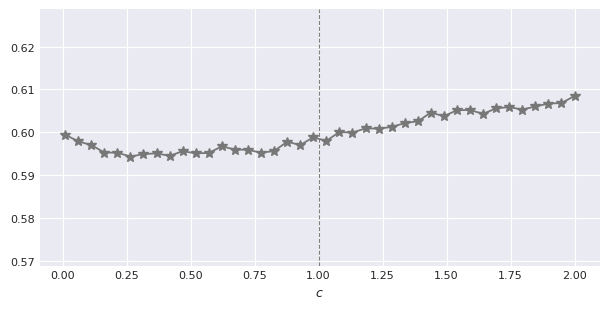

  0%|          | 0/200 [00:00<?, ?it/s]

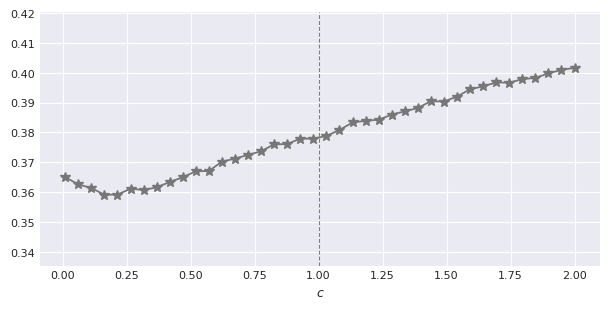

In [ ]:
mult_grid = np.linspace(0.01, 2, 40)

# normal error
arr_n, mspe_n, grid = run_nn_huber_sensitivity(
    M=200, n=4096, mult_grid=mult_grid, error='normal',
    type='EXPAR_v1', v=0.5, exponent=.2, n_jobs=200)
np.save('./res_nolinear/sens_nn_normal.npy', arr_n)
a=plot_nn_huber_sensitivity(
    grid, mspe_n,
    fname='./res_nolinear/sens_nn_normal.pdf', anchor='default')

# t error
arr_t, mspe_t, grid = run_nn_huber_sensitivity(
    M=200, n=8192, mult_grid=mult_grid, error='t',
    type='EXPAR_v1', v=0.5, exponent=.2, n_jobs=200)
np.save('./res_nolinear/sens_nn_t.npy', arr_t)
b=plot_nn_huber_sensitivity(
    grid, mspe_t,
    fname='./res_nolinear/sens_nn_t.pdf', anchor='default')
